# Ablation experiment: PR dataset vs. semantic PR features

Este notebook compara, sobre **exactamente las mismas PRs y el mismo split train/validación**, tres modelos XGBoost:

1. sólo features tabulares de `pr_datasets.csv`;
2. sólo features semánticas de `data/output/pr_features.csv`;
3. ambas fuentes combinadas mediante `pr_url`.

No hay test set, tracking, búsqueda de hiperparámetros ni persistencia de modelos. El objetivo es una prueba rápida de aporte incremental.

> **Chequeo de procedencia pendiente:** el flujo actual de `scripts/run_block.py` pasa `is_merged` a `pipeline/process_block.py`; ese módulo agrega `Merged: yes/no` y elige un prompt distinto por clase. Si este CSV se generó con ese flujo, existe fuga del target. El notebook no puede confirmar por sí solo la procedencia exacta del archivo, por lo que reporta el riesgo sin asumirlo como hecho.

Decisiones basadas en documentación oficial: métricas PR/ROC de [scikit-learn](https://scikit-learn.org/stable/modules/model_evaluation.html), y XGBoost `hist` y early stopping según la [interfaz sklearn de XGBoost](https://xgboost.readthedocs.io/en/stable/python/sklearn_estimator.html) y sus [parámetros](https://xgboost.readthedocs.io/en/stable/parameter.html).

In [2]:
from __future__ import annotations

import hashlib
import platform
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import xgboost
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

RANDOM_STATE = 42
VALIDATION_SIZE = 0.10
ROOT = Path.cwd().resolve()
if not (ROOT / 'data' / 'pr_datasets_filtered.csv').exists():
    ROOT = ROOT.parent
BASE_CSV = ROOT / 'data' / 'pr_datasets_filtered.csv'
SEMANTIC_CSV = ROOT / 'data' / 'pr_features.csv'

assert BASE_CSV.exists(), f'No se encontró {BASE_CSV}'
assert SEMANTIC_CSV.exists(), f'No se encontró {SEMANTIC_CSV}'

print({
    'python': platform.python_version(),
    'pandas': pd.__version__,
    'scikit_learn': sklearn.__version__,
    'xgboost': xgboost.__version__,
})

{'python': '3.13.13', 'pandas': '2.3.3', 'scikit_learn': '1.9.0', 'xgboost': '3.3.0'}


## 1. Carga, deduplicación y cruce

Las duplicadas de `pr_features.csv` son reintentos/apéndices del proceso. Se verifica primero que no tengan etiquetas contradictorias y se conserva la última ocurrencia. El CSV base se lee por chunks y sólo se retienen URLs presentes en las features semánticas, para no mantener en memoria las 475k filas ni los campos textuales pesados.

In [3]:
semantic_raw = pd.read_csv(SEMANTIC_CSV, low_memory=False)
required_semantic = {'pr_url', 'merge'}
assert required_semantic <= set(semantic_raw.columns)

duplicate_mask = semantic_raw.duplicated('pr_url', keep=False)
label_conflicts = (
    semantic_raw.loc[duplicate_mask].groupby('pr_url')['merge'].nunique().gt(1).sum()
)
assert label_conflicts == 0, 'Hay pr_url duplicadas con etiquetas contradictorias.'

semantic = semantic_raw.drop_duplicates('pr_url', keep='last').copy()
print({
    'filas_semantic_raw': len(semantic_raw),
    'urls_duplicadas_extra': int(semantic_raw.duplicated('pr_url').sum()),
    'urls_semantic_unicas': semantic['pr_url'].nunique(),
    'conflictos_de_etiqueta': int(label_conflicts),
})

{'filas_semantic_raw': 19174, 'urls_duplicadas_extra': 64, 'urls_semantic_unicas': 19110, 'conflictos_de_etiqueta': 0}


In [4]:
# Exclusiones explícitas del dataset base.
BASE_EXCLUSIONS = {
    'pr_url': 'clave de join / identificador',
    'merge': 'etiqueta',
    'github_merge': 'componente directo de la etiqueta',
    'comment_merge': 'componente directo de la etiqueta',
    'commit_merge': 'componente directo de la etiqueta',
    'closed_at': 'dato posterior al momento de predicción',
    'login': 'identificador de alta cardinalidad',
    'body': 'texto crudo fuera del alcance del modelo tabular rápido',
    'title': 'texto crudo fuera del alcance del modelo tabular rápido',
    'commit_message': 'texto crudo fuera del alcance del modelo tabular rápido',
    'code_patch_diff': 'diff crudo, extremadamente pesado y fuera de alcance',
}
SEQUENCE_COLUMNS = [
    'everyday_pr_comment_count_in_lifetime',
    'everyday_pr_commit_count_in_lifetime',
]

base_columns = pd.read_csv(BASE_CSV, nrows=0).columns.tolist()
base_predictor_columns = [c for c in base_columns if c not in BASE_EXCLUSIONS]
# closed_at se carga sólo para auditar el corte temporal; nunca entra al modelo.
base_usecols = ['pr_url', 'merge', 'closed_at', *base_predictor_columns]
target_urls = set(semantic['pr_url'])

started = time.perf_counter()
matched_chunks = []
base_row_count = 0
for chunk in pd.read_csv(BASE_CSV, usecols=base_usecols, chunksize=50_000, low_memory=False):
    base_row_count += len(chunk)
    matched = chunk.loc[chunk['pr_url'].isin(target_urls)]
    if not matched.empty:
        matched_chunks.append(matched)
base = pd.concat(matched_chunks, ignore_index=True)

assert not base['pr_url'].duplicated().any(), 'El dataset base tiene URLs duplicadas.'
joined_label_check = base[['pr_url', 'merge']].merge(
    semantic[['pr_url', 'merge']], on='pr_url', suffixes=('_base', '_semantic'), validate='one_to_one'
)
label_mismatches = joined_label_check['merge_base'].ne(joined_label_check['merge_semantic']).sum()
assert label_mismatches == 0, 'Las etiquetas difieren entre fuentes.'

print({
    'filas_base_totales': base_row_count,
    'filas_en_interseccion': len(base),
    'urls_solo_semantic': len(target_urls - set(base['pr_url'])),
    'mismatches_etiqueta': int(label_mismatches),
    'segundos_lectura_base': round(time.perf_counter() - started, 2),
})

{'filas_base_totales': 18934, 'filas_en_interseccion': 18934, 'urls_solo_semantic': 176, 'mismatches_etiqueta': 0, 'segundos_lectura_base': 0.33}


## 2. Limpieza de features

En `pr_features` se eliminan `repo`, `pr_number`, `bloque`, `elapsed_seconds`, `pr_url` y `merge`: son identidad, control operacional, tiempo de extracción o target, no propiedades predictivas del cambio. En el dataset base se excluyen además los componentes directos del target y datos disponibles sólo después del cierre. Las dos secuencias históricas se resumen sin usar información de validación. Finalmente se eliminan columnas constantes y duplicadas exactas.

In [5]:
SEMANTIC_EXCLUSIONS = {
    'pr_url': 'clave de join / identificador',
    'merge': 'etiqueta',
    'repo': 'identificador del repositorio',
    'pr_number': 'identificador/proxy temporal de la PR',
    'bloque': 'control operacional y constante en esta extracción',
    'elapsed_seconds': 'tiempo operacional de extracción',
}

def sequence_summaries(series: pd.Series, prefix: str) -> pd.DataFrame:
    def parse(value: object) -> np.ndarray:
        if pd.isna(value) or str(value).strip() == '':
            return np.array([], dtype=float)
        return np.asarray([float(item) for item in str(value).split(';')], dtype=float)

    arrays = series.map(parse)
    return pd.DataFrame({
        f'{prefix}__sum': arrays.map(lambda x: float(x.sum()) if x.size else np.nan),
        f'{prefix}__mean': arrays.map(lambda x: float(x.mean()) if x.size else np.nan),
        f'{prefix}__max': arrays.map(lambda x: float(x.max()) if x.size else np.nan),
        f'{prefix}__nonzero_periods': arrays.map(lambda x: int(np.count_nonzero(x)) if x.size else np.nan),
    }, index=series.index)

def coerce_model_dtypes(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame.copy()
    for column in result.columns:
        if pd.api.types.is_bool_dtype(result[column]):
            result[column] = result[column].astype('int8')
        elif not pd.api.types.is_numeric_dtype(result[column]):
            parsed = pd.to_numeric(result[column], errors='coerce')
            if parsed.notna().sum() == result[column].notna().sum():
                result[column] = parsed
    return result

def drop_uninformative(frame: pd.DataFrame) -> tuple[pd.DataFrame, list[str], dict[str, str]]:
    constants = [c for c in frame if frame[c].nunique(dropna=False) <= 1]
    reduced = frame.drop(columns=constants)
    fingerprints: dict[tuple[str, str], str] = {}
    duplicates: dict[str, str] = {}
    for column in reduced.columns:
        hashed = pd.util.hash_pandas_object(reduced[column], index=False).values.tobytes()
        key = (str(reduced[column].dtype), hashlib.sha256(hashed).hexdigest())
        prior = fingerprints.get(key)
        if prior is not None and reduced[column].equals(reduced[prior]):
            duplicates[column] = prior
        else:
            fingerprints[key] = column
    return reduced.drop(columns=list(duplicates)), constants, duplicates

# El orden del dataset base se conserva para poder hacer un corte temporal/ordinal.
common_urls = base['pr_url'].tolist()
base_indexed = base.set_index('pr_url').loc[common_urls]
semantic_indexed = semantic.set_index('pr_url').loc[common_urls]
y = base_indexed['merge'].astype('int8')

X_base = base_indexed.drop(columns=['merge', 'closed_at']).copy()
for sequence_column in SEQUENCE_COLUMNS:
    if sequence_column in X_base:
        X_base = pd.concat(
            [X_base.drop(columns=sequence_column), sequence_summaries(X_base[sequence_column], sequence_column)],
            axis=1,
        )
X_base = coerce_model_dtypes(X_base)
X_base, base_constants, base_duplicates = drop_uninformative(X_base)

semantic_feature_columns = [c for c in semantic_indexed.columns if c not in SEMANTIC_EXCLUSIONS]
X_semantic = coerce_model_dtypes(semantic_indexed[semantic_feature_columns])
X_semantic, semantic_constants, semantic_duplicates = drop_uninformative(X_semantic)

X_combined = pd.concat(
    [X_base.add_prefix('base__'), X_semantic.add_prefix('semantic__')], axis=1
)

cleaning_report = pd.DataFrame([
    {'source': 'pr_dataset', 'features_finales': X_base.shape[1], 'constantes_eliminadas': base_constants, 'duplicadas_eliminadas': base_duplicates},
    {'source': 'pr_features', 'features_finales': X_semantic.shape[1], 'constantes_eliminadas': semantic_constants, 'duplicadas_eliminadas': semantic_duplicates},
])
display(cleaning_report)
display(pd.DataFrame({'motivo': BASE_EXCLUSIONS}).rename_axis('columna').reset_index())
display(pd.DataFrame({'motivo': SEMANTIC_EXCLUSIONS}).rename_axis('columna').reset_index())

,source,features_finales,constantes_eliminadas,duplicadas_eliminadas
0,pr_dataset,58,[],{}
1,pr_features,26,[],{}


,columna,motivo
0,pr_url,clave de join / identificador
1,merge,etiqueta
2,github_merge,componente directo de la etiqueta
3,comment_merge,componente directo de la etiqueta
4,commit_merge,componente directo de la etiqueta
5,closed_at,dato posterior al momento de predicción
6,login,identificador de alta cardinalidad
7,body,texto crudo fuera del alcance del modelo tabul...
8,title,texto crudo fuera del alcance del modelo tabul...
9,commit_message,texto crudo fuera del alcance del modelo tabul...


,columna,motivo
0,pr_url,clave de join / identificador
1,merge,etiqueta
2,repo,identificador del repositorio
3,pr_number,identificador/proxy temporal de la PR
4,bloque,control operacional y constante en esta extrac...
5,elapsed_seconds,tiempo operacional de extracción


## 3. Un único split temporal train/validación

Se conserva el orden original de `pr_datasets.csv`: el primer 90% se usa como train y el último 10% como validación, sin shuffle, sin estratificación y sin test. El mismo corte se reutiliza en los tres escenarios. Todos los transformadores se ajustan exclusivamente con train. `closed_at` no se usa como feature porque corresponde al resultado/cierre de la PR.

In [6]:
split_position = int(len(y) * (1 - VALIDATION_SIZE))
train_positions = np.arange(split_position)
validation_positions = np.arange(split_position, len(y))
y_train = y.iloc[train_positions]
y_validation = y.iloc[validation_positions]

split_report = pd.DataFrame({
    'split': ['total', 'train', 'validation'],
    'rows': [len(y), len(y_train), len(y_validation)],
    'merged': [int(y.sum()), int(y_train.sum()), int(y_validation.sum())],
    'not_merged': [int((1-y).sum()), int((1-y_train).sum()), int((1-y_validation).sum())],
    'merged_rate': [y.mean(), y_train.mean(), y_validation.mean()],
})
display(split_report.style.format({'merged_rate': '{:.2%}'}))
closed_at = pd.to_datetime(base_indexed['closed_at'], utc=True, errors='raise')
temporal_audit = pd.DataFrame({
    'split': ['train', 'validation'],
    'closed_at_min': [closed_at.iloc[train_positions].min(), closed_at.iloc[validation_positions].min()],
    'closed_at_max': [closed_at.iloc[train_positions].max(), closed_at.iloc[validation_positions].max()],
})
display(temporal_audit)
print('closed_at globalmente monotónico:', closed_at.is_monotonic_increasing)
assert closed_at.is_monotonic_increasing, 'El orden del CSV no es temporal según closed_at.'
assert closed_at.iloc[train_positions].max() <= closed_at.iloc[validation_positions].min()
print('El modelo no aplica pesos de clase; el desbalance se refleja con métricas por clase y balanced accuracy.')

assert set(train_positions).isdisjoint(validation_positions)
assert len(train_positions) + len(validation_positions) == len(y)

,split,rows,merged,not_merged,merged_rate
0,total,18934,12918,6016,68.23%
1,train,17040,11746,5294,68.93%
2,validation,1894,1172,722,61.88%


,split,closed_at_min,closed_at_max
0,train,2010-09-03 08:24:32+00:00,2019-07-31 12:02:48+00:00
1,validation,2019-07-31 15:07:45+00:00,2021-09-14 02:27:00+00:00


closed_at globalmente monotónico: True
El modelo no aplica pesos de clase; el desbalance se refleja con métricas por clase y balanced accuracy.


## 4. Preprocesamiento, XGBoost y métricas

Las numéricas llevan imputación por mediana; las categóricas, valor explícito para faltantes y one-hot con categorías raras agrupadas. XGBoost usa parámetros fijos (sin tuning), árboles histogram y early stopping sobre validación. Reportamos AP para ambas clases porque `merge=1` es mayoritaria; AP de `not_merged` mide mejor la clase minoritaria.

In [7]:
def build_preprocessor(frame: pd.DataFrame) -> ColumnTransformer:
    numeric_columns = frame.select_dtypes(include=np.number).columns.tolist()
    categorical_columns = [c for c in frame.columns if c not in numeric_columns]
    numeric_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ])
    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='__MISSING__')),
        ('encoder', OneHotEncoder(
            handle_unknown='infrequent_if_exist',
            min_frequency=5,
            sparse_output=True,
        )),
    ])
    return ColumnTransformer(
        [('numeric', numeric_pipeline, numeric_columns), ('categorical', categorical_pipeline, categorical_columns)],
        sparse_threshold=1.0,
        verbose_feature_names_out=True,
    )

def evaluate_predictions(name: str, y_true: pd.Series, probability: np.ndarray) -> dict[str, float | str]:
    prediction = (probability >= 0.5).astype('int8')
    report = classification_report(y_true, prediction, output_dict=True, zero_division=0)
    return {
        'scenario': name,
        'roc_auc': roc_auc_score(y_true, probability),
        'ap_merged': average_precision_score(y_true, probability),
        'ap_not_merged': average_precision_score(1 - y_true, 1 - probability),
        'balanced_accuracy': balanced_accuracy_score(y_true, prediction),
        'accuracy': accuracy_score(y_true, prediction),
        'f1_merged': f1_score(y_true, prediction, pos_label=1),
        'f1_not_merged': f1_score(y_true, prediction, pos_label=0),
        'recall_merged': report['1']['recall'],
        'recall_not_merged': report['0']['recall'],
        'confusion_matrix_[tn_fp;fn_tp]': confusion_matrix(y_true, prediction).tolist(),
    }

def train_scenario(name: str, frame: pd.DataFrame):
    X_train = frame.iloc[train_positions].copy()
    X_validation = frame.iloc[validation_positions].copy()
    preprocessor = build_preprocessor(X_train)
    transformed_train = preprocessor.fit_transform(X_train)
    transformed_validation = preprocessor.transform(X_validation)

    model = XGBClassifier(
        objective='binary:logistic',
        n_estimators=1_000,
        learning_rate=0.05,
        max_depth=5,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        scale_pos_weight=1.0,
        tree_method='hist',
        eval_metric=['logloss', 'aucpr'],
        early_stopping_rounds=50,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    started = time.perf_counter()
    model.fit(
        transformed_train,
        y_train,
        eval_set=[(transformed_validation, y_validation)],
        verbose=False,
    )
    elapsed = time.perf_counter() - started
    probability = model.predict_proba(transformed_validation)[:, 1]
    metrics = evaluate_predictions(name, y_validation, probability)
    metrics.update({
        'raw_features': frame.shape[1],
        'encoded_features': transformed_train.shape[1],
        'best_iteration': model.best_iteration,
        'train_seconds': elapsed,
    })

    transformed_names = preprocessor.get_feature_names_out()
    importance = pd.DataFrame({
        'feature': transformed_names,
        'importance_gain_normalized': model.feature_importances_,
    }).sort_values('importance_gain_normalized', ascending=False, ignore_index=True)
    return metrics, preprocessor, model, importance


In [8]:
dummy = DummyClassifier(strategy='prior')
dummy.fit(np.zeros((len(y_train), 1)), y_train)
dummy_probability = dummy.predict_proba(np.zeros((len(y_validation), 1)))[:, 1]
all_metrics = [evaluate_predictions('dummy_prior', y_validation, dummy_probability)]
artifacts = {}

for scenario_name, frame in {
    'pr_dataset_only': X_base,
    'pr_features_only': X_semantic,
    'combined': X_combined,
}.items():
    print(f'Entrenando {scenario_name} ({frame.shape[1]} features crudas)...')
    metrics, preprocessor, model, importance = train_scenario(scenario_name, frame)
    all_metrics.append(metrics)
    artifacts[scenario_name] = {
        'preprocessor': preprocessor,
        'model': model,
        'importance': importance,
    }
    print(f"  listo en {metrics['train_seconds']:.2f}s, best_iteration={metrics['best_iteration']}")

Entrenando pr_dataset_only (58 features crudas)...


  listo en 0.76s, best_iteration=56
Entrenando pr_features_only (26 features crudas)...


  listo en 1.17s, best_iteration=219
Entrenando combined (84 features crudas)...


  listo en 3.41s, best_iteration=62


## 5. Resultados comparables

In [9]:
results = pd.DataFrame(all_metrics).set_index('scenario')
metric_columns = [
    'roc_auc', 'ap_merged', 'ap_not_merged', 'balanced_accuracy',
    'accuracy', 'f1_merged', 'f1_not_merged', 'recall_merged', 'recall_not_merged',
]
display(results[metric_columns].style.format('{:.4f}').highlight_max(axis=0, color='#d7f5d0'))
display(results[[
    'raw_features', 'encoded_features', 'best_iteration', 'train_seconds',
    'confusion_matrix_[tn_fp;fn_tp]',
]])

deltas = results.loc[['pr_features_only', 'combined'], metric_columns] - results.loc['pr_dataset_only', metric_columns]
deltas.index = ['pr_features - pr_dataset', 'combined - pr_dataset']
print('Deltas absolutos contra pr_dataset_only:')
display(deltas.style.format('{:+.4f}').background_gradient(cmap='RdYlGn', axis=None, vmin=-0.1, vmax=0.1))

,roc_auc,ap_merged,ap_not_merged,balanced_accuracy,accuracy,f1_merged,f1_not_merged,recall_merged,recall_not_merged
scenario,,,,,,,,,
dummy_prior,0.5000,0.6188,0.3812,0.5000,0.6188,0.7645,0.0000,1.0000,0.0000
pr_dataset_only,0.8280,0.8886,0.7536,0.6745,0.7413,0.8205,0.5369,0.9556,0.3934
pr_features_only,0.7736,0.8107,0.7308,0.6489,0.7254,0.8140,0.4758,0.9710,0.3269
combined,0.8828,0.9197,0.8482,0.7121,0.7767,0.8450,0.6006,0.9838,0.4404


,raw_features,encoded_features,best_iteration,train_seconds,confusion_matrix_[tn_fp;fn_tp]
scenario,,,,,
dummy_prior,NaN,NaN,NaN,NaN,"[[0, 722], [0, 1172]]"
pr_dataset_only,58.0,85.0,56.0,0.760856,"[[284, 438], [52, 1120]]"
pr_features_only,26.0,173.0,219.0,1.170607,"[[236, 486], [34, 1138]]"
combined,84.0,258.0,62.0,3.410123,"[[318, 404], [19, 1153]]"


Deltas absolutos contra pr_dataset_only:


,roc_auc,ap_merged,ap_not_merged,balanced_accuracy,accuracy,f1_merged,f1_not_merged,recall_merged,recall_not_merged
pr_features - pr_dataset,-0.0543,-0.0779,-0.0227,-0.0256,-0.0158,-0.0065,-0.0611,+0.0154,-0.0665
combined - pr_dataset,+0.0549,+0.0311,+0.0946,+0.0376,+0.0354,+0.0245,+0.0637,+0.0282,+0.0471


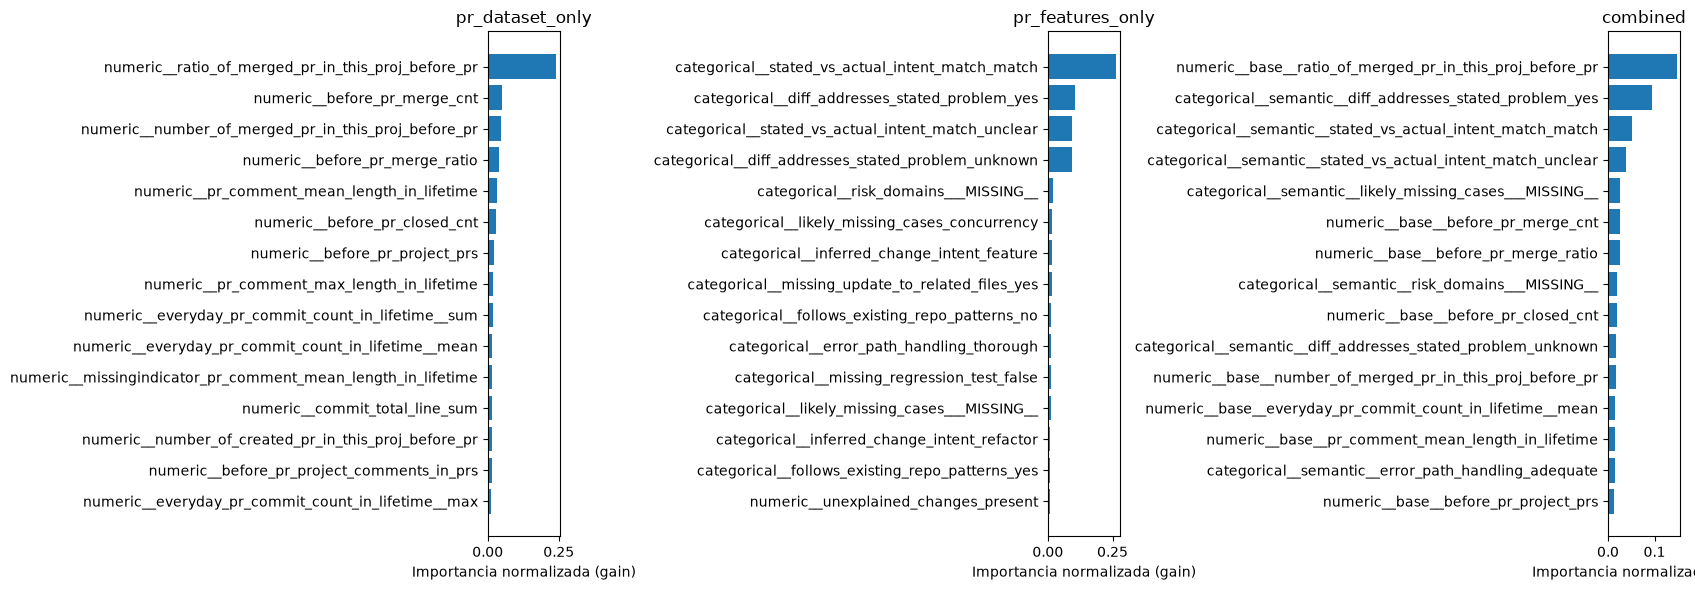

Uso de cada fuente dentro del modelo combinado:


,source,total_importance,encoded_features,nonzero_features
0,pr_dataset,50.45%,85,55
1,pr_features,49.55%,173,51


Top 25 features codificadas del modelo combinado:


,feature,importance_gain_normalized,source
0,numeric__base__ratio_of_merged_pr_in_this_proj...,0.147434,pr_dataset
1,categorical__semantic__diff_addresses_stated_p...,0.093881,pr_features
2,categorical__semantic__stated_vs_actual_intent...,0.052676,pr_features
3,categorical__semantic__stated_vs_actual_intent...,0.038227,pr_features
4,categorical__semantic__likely_missing_cases___...,0.026911,pr_features
5,numeric__base__before_pr_merge_cnt,0.026467,pr_dataset
6,numeric__base__before_pr_merge_ratio,0.025002,pr_dataset
7,categorical__semantic__risk_domains___MISSING__,0.020158,pr_features
8,numeric__base__before_pr_closed_cnt,0.019794,pr_dataset
9,categorical__semantic__diff_addresses_stated_p...,0.017080,pr_features


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
for axis, scenario_name in zip(axes, ['pr_dataset_only', 'pr_features_only', 'combined']):
    top = artifacts[scenario_name]['importance'].head(15).sort_values('importance_gain_normalized')
    axis.barh(top['feature'], top['importance_gain_normalized'])
    axis.set_title(scenario_name)
    axis.set_xlabel('Importancia normalizada (gain)')
plt.tight_layout()
plt.show()

combined_importance = artifacts['combined']['importance'].copy()
combined_importance['source'] = np.where(
    combined_importance['feature'].str.contains('semantic__', regex=False),
    'pr_features',
    'pr_dataset',
)
source_contribution = (
    combined_importance.groupby('source', as_index=False)
    .agg(
        total_importance=('importance_gain_normalized', 'sum'),
        encoded_features=('feature', 'size'),
        nonzero_features=('importance_gain_normalized', lambda s: int((s > 0).sum())),
    )
    .sort_values('total_importance', ascending=False)
)
print('Uso de cada fuente dentro del modelo combinado:')
display(source_contribution.style.format({'total_importance': '{:.2%}'}))
print('Top 25 features codificadas del modelo combinado:')
display(combined_importance.head(25))

## 6. Lectura automática y límites

La tabla responde qué fuente mejora las métricas en esta única validación. La suma de importancia por fuente indica si XGBoost usó ambas dentro del modelo combinado, pero **no es una estimación causal** del aporte de cada feature.

In [ ]:
best_by_minority_ap = results.loc[results['ap_not_merged'].idxmax()]
best_name = results['ap_not_merged'].idxmax()
combined_delta = results.loc['combined', 'ap_not_merged'] - results.loc['pr_dataset_only', 'ap_not_merged']
semantic_share = source_contribution.set_index('source').loc['pr_features', 'total_importance']

print(f'Mejor AP para no-mergeadas: {best_name} ({best_by_minority_ap["ap_not_merged"]:.4f}).')
print(f'Delta del combinado vs. base en AP no-mergeadas: {combined_delta:+.4f}.')
print(f'Importancia normalizada atribuida a pr_features dentro del combinado: {semantic_share:.2%}.')


Mejor AP para no-mergeadas: combined (0.8482).
Delta del combinado vs. base en AP no-mergeadas: +0.0946.
Importancia normalizada atribuida a pr_features dentro del combinado: 49.55%.

Cautela de procedencia: si pr_features fue generado por el flujo actual run_block/process_block,
el extractor recibió merge y los resultados semánticos tienen riesgo de target leakage.
Confirmar el comando/versión que produjo el CSV antes de interpretar la mejora como generalización.
